# Surrogate Evaluation

In [1]:
import os
import numpy as np
import xarray as xr
import pyarts

from util import (
    SPECIES,
    MOLAR_MASS,
    DEFAULT_F_ARRAY,
    assert_strictly_decreasing,
    make_sampling_grids_from_envelope,
    report_sampling_vs_envelope,
    coerce_coeffs_wvn_by_features,
    derivative_matrix,
    set_cost_dimensions,
    evaluate_column_costs,
    compute_global_costs_ddq_vs_dense,
    summarize_column_rms_flux_heating,
    plot_column_rms_histograms_labeled,
    plot_flux_vs_heating_rms_scatter,
)
# Ensure spectroscopy tables are available
pyarts.cat.download.retrieve()

## Sampling grids and DDQ weights

In [2]:
profiles_full = xr.open_dataset("ckdmip_evaluation1_concentrations_present.nc")
profiles = profiles_full.isel(column=0)

T_set, p_hl_grid = make_sampling_grids_from_envelope(
    profiles_full, nT=9, nP=55, T_pad=0.05, p_pad=0.05, p_top_floor=1e-2
)
assert_strictly_decreasing(p_hl_grid, "p_hl_grid")
report_sampling_vs_envelope(profiles_full, T_set, p_hl_grid, p_top_floor=1e-2)

DDQ_lw = xr.open_dataset("~/DDQ_LW_present.h5", engine="netcdf4")
DDQ_lw.compute()
nu_cm1 = DDQ_lw.S.values.astype(float)
weights = DDQ_lw.W.values.astype(float)
print(f"Sampling κ on T×p grid: T={T_set.size}, p={p_hl_grid.size}, ν={nu_cm1.size}")

CKDMIP envelope: p∈[1.00e-02,1.03e+05] Pa, T∈[169.1,326.2] K
Sampling grids : p∈[1.00e-02,1.08e+05] Pa (surf→TOA), T∈[160.6,342.5] K
✅ Sampling covers CKDMIP and extends a little outside.
Sampling κ on T×p grid: T=9, p=55, ν=64


## Cost configuration

In [3]:
# Grid setup shared by cost_no_forcing
N_SCENARIOS = 1
N_COLS = 1
N_LEVELS = profiles.pressure_hl.size
F_ARRAY = DEFAULT_F_ARRAY.copy()
set_cost_dimensions(N_LEVELS, N_COLS, N_SCENARIOS, f_array=F_ARRAY)

mat = derivative_matrix(N_LEVELS)
nu_dense = np.linspace(10.0, 3260.0, 30000)

DENSE_CACHE_DIR = "lbl_dense"
DDQ_CACHE_DIR = "lbl_ddq"

## Fit Cache Directory

In [4]:
FIT_CACHE_DIR = "fit_cache"
os.makedirs(FIT_CACHE_DIR, exist_ok=True)

## Error bookkeeping

We compute two sources of error:

- `cost_ddq_vs_dense`: quadrature error from using Paulina's DDQ nodes/weights instead of the dense ARTS grid.
- `cost_surrogate_vs_ddq`: surrogate κ error relative to ARTS run directly on the DDQ nodes.

Both are returned per-column and globally so we can compare surrogate error against the inherent DDQ quadrature error.



## 1. Log-Poly Surrogate Evaluation

In [5]:
# Cached κ(T,p) fits should already live under fit_cache/
fits = {}
for sp in SPECIES:
    cache_file = os.path.join(FIT_CACHE_DIR, f"{sp.lower()}_fit_data.npz")
    if os.path.exists(cache_file):
        print(f"[{sp}] Loading pre-computed fit data from {cache_file}...")
        data = np.load(cache_file)
        fits[sp] = {
            "coeffs": data["coeffs"],
            "P_used": data["P_used"],
            "T_used": data["T_used"],
            "nu": data.get("nu"),
        }
        print(f"[{sp}] ✓ Loaded.")
    else:
        print(f"[{sp}] ❌ Missing cache at {cache_file} — run the fitting step before evaluations.")

if set(fits.keys()) != set(SPECIES):
    missing = set(SPECIES) - set(fits.keys())
    raise RuntimeError(f"Missing fit caches for: {', '.join(sorted(missing))}")

coeffs_CO2_raw = fits["CO2"]["coeffs"]
coeffs_O3_raw = fits["O3"]["coeffs"]
nu_CO2_fit = fits["CO2"].get("nu") or nu_cm1
nu_O3_fit = fits["O3"].get("nu") or nu_cm1

coeffs_CO2 = coerce_coeffs_wvn_by_features(coeffs_CO2_raw, nu_CO2_fit, nu_cm1)
coeffs_O3 = coerce_coeffs_wvn_by_features(coeffs_O3_raw, nu_O3_fit, nu_cm1)

kappa_coeffs_by_species = {"CO2": coeffs_CO2, "O3": coeffs_O3}
print("✓ Surrogate coefficient matrices aligned to DDQ grid.")

[CO2] Loading pre-computed fit data from fit_cache/co2_fit_data.npz...
[CO2] ✓ Loaded.
[O3] Loading pre-computed fit data from fit_cache/o3_fit_data.npz...
[O3] ✓ Loaded.
✓ Surrogate coefficient matrices aligned to DDQ grid.


## Single-column check

In [6]:
column_eval = evaluate_column_costs(
    col_idx=0,
    profiles=profiles_full,
    DDQ_lw=DDQ_lw,
    nu_dense_cm1=nu_dense,
    kappa_coeffs_dict=kappa_coeffs_by_species,
    molar_mass_dict=MOLAR_MASS,
    target_species_list=("CO2", "O3"),
    dense_cache_dir=DENSE_CACHE_DIR,
    ddq_cache_dir=DDQ_CACHE_DIR,
)

print(f"[col 0] Cost (DDQ baseline vs dense): {column_eval['cost_ddq_vs_dense']:.6f}")
print(f"[col 0] Cost (surrogate vs DDQ): {column_eval['cost_surrogate_vs_ddq']:.6f}")
print(f"[col 0] Cost (surrogate vs dense): {column_eval['cost_surrogate_vs_dense']:.6f}")

Loading dense LBL data for col 0 from cache: lbl_dense/dense_lbl_col_000.npz
[col 0] Cost (DDQ baseline vs dense): 13.313401
[col 0] Cost (surrogate vs DDQ): 4.291162
[col 0] Cost (surrogate vs dense): 16.720138


## Global evaluation

In [7]:
global_costs = compute_global_costs_ddq_vs_dense(
    profiles=profiles_full,
    DDQ_lw=DDQ_lw,
    nu_dense_cm1=nu_dense,
    kappa_coeffs_dict=kappa_coeffs_by_species,
    molar_mass_dict=MOLAR_MASS,
    target_species_list=("CO2", "O3"),
    dense_cache_dir=DENSE_CACHE_DIR,
    ddq_cache_dir=DDQ_CACHE_DIR,
)

print(f"Global cost (surrogate vs dense) for reference: {global_costs['cost_surrogate_vs_dense']:.6f}")

/srv/conda/envs/ddq_fluxsim_tutorial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global DDQ vs dense:   0%|                               | 0/50 [00:00<?, ?it/s]

Loading dense LBL data for col 0 from cache: lbl_dense/dense_lbl_col_000.npz


Global DDQ vs dense:   2%|▍                      | 1/50 [00:00<00:35,  1.39it/s]

Loading dense LBL data for col 1 from cache: lbl_dense/dense_lbl_col_001.npz


Global DDQ vs dense:   4%|▉                      | 2/50 [00:01<00:35,  1.36it/s]

...

Loading dense LBL data for col 48 from cache: lbl_dense/dense_lbl_col_048.npz


Global DDQ vs dense:  98%|█████████████████████▌| 49/50 [00:34<00:00,  1.40it/s]

Loading dense LBL data for col 49 from cache: lbl_dense/dense_lbl_col_049.npz


Global DDQ vs dense: 100%|██████████████████████| 50/50 [00:35<00:00,  1.41it/s]

Global cost (DDQ baseline vs dense): 112.379640  |  Global cost (surrogate vs DDQ): 31.838688
Global cost (surrogate vs dense) for reference: 137.715590


## 2. PLS surrogate Evaluation

In [8]:
# Load κ_m arrays predicted per column/level on the DDQ grid
n_cols = int(profiles_full.sizes["column"])

def load_kappa_arrays(prefix):
    
    with np.load(os.path.join(FIT_CACHE_DIR, f"kappas_pred_CO2_{prefix}.npz")) as data:
        co2 = data["data1"]
    with np.load(os.path.join(FIT_CACHE_DIR, f"kappas_pred_O3_{prefix}.npz")) as data:
        o3 = data["data1"]
    return {"CO2": co2[:, :n_cols, :], "O3": o3[:, :n_cols, :]}

kappa_arrays_pls = load_kappa_arrays("PLS")

global_costs_pls = compute_global_costs_ddq_vs_dense(
    profiles=profiles_full,
    DDQ_lw=DDQ_lw,
    nu_dense_cm1=nu_dense,
    kappa_coeffs_dict=kappa_coeffs_by_species,
    molar_mass_dict=MOLAR_MASS,
    target_species_list=("CO2", "O3"),
    dense_cache_dir=DENSE_CACHE_DIR,
    ddq_cache_dir=DDQ_CACHE_DIR,
    kappa_arrays_dict=kappa_arrays_pls,
)

print(
    f"[PLS κ arrays] DDQ vs dense: {global_costs_pls['cost_ddq_vs_dense']:.6f} | "
    f"Surrogate vs DDQ: {global_costs_pls['cost_surrogate_vs_ddq']:.6f} | "
    f"Surrogate vs dense: {global_costs_pls['cost_surrogate_vs_dense']:.6f}"
)

Global DDQ vs dense:   0%|                               | 0/50 [00:00<?, ?it/s]

Loading dense LBL data for col 0 from cache: lbl_dense/dense_lbl_col_000.npz


Global DDQ vs dense:   2%|▍                      | 1/50 [00:00<00:34,  1.40it/s]

Loading dense LBL data for col 1 from cache: lbl_dense/dense_lbl_col_001.npz


Global DDQ vs dense:   4%|▉                      | 2/50 [00:01<00:33,  1.43it/s]

...

Loading dense LBL data for col 48 from cache: lbl_dense/dense_lbl_col_048.npz


Global DDQ vs dense:  98%|█████████████████████▌| 49/50 [00:34<00:00,  1.40it/s]

Loading dense LBL data for col 49 from cache: lbl_dense/dense_lbl_col_049.npz


Global DDQ vs dense: 100%|██████████████████████| 50/50 [00:35<00:00,  1.40it/s]

Global cost (DDQ baseline vs dense): 112.379640  |  Global cost (surrogate vs DDQ): 10780.849651
[PLS κ arrays] DDQ vs dense: 112.379640 | Surrogate vs DDQ: 10780.849651 | Surrogate vs dense: 10755.627085


## Cost visualizations (per-column RMS)

We plot **per-column RMS** of net flux and heating errors for:

- **Log-poly surrogate** vs DDQ and vs dense
- **PLS surrogate** vs DDQ and vs dense

In [9]:
# Log-poly: surrogate vs DDQ, surrogate vs dense
logpoly_vs_ddq = summarize_column_rms_flux_heating(
    F_hat_level_col=global_costs["F_surrogate"],
    F_ref_level_col=global_costs["F_ref_ddq"],
    pressures_col_level=global_costs["pressures_ddq"],
    H_ref_col_level=global_costs["H_ref_ddq"],
    label="Log-poly",
    scenario="Surrogate vs DDQ",
)
logpoly_vs_dense = summarize_column_rms_flux_heating(
    F_hat_level_col=global_costs["F_surrogate"],
    F_ref_level_col=global_costs["F_ref_dense"],
    pressures_col_level=global_costs["pressures_dense"],
    H_ref_col_level=global_costs["H_ref_dense"],
    label="Log-poly",
    scenario="Surrogate vs Dense",
)

# PLS: surrogate vs DDQ, surrogate vs dense
pls_vs_ddq = summarize_column_rms_flux_heating(
    F_hat_level_col=global_costs_pls["F_surrogate"],
    F_ref_level_col=global_costs_pls["F_ref_ddq"],
    pressures_col_level=global_costs_pls["pressures_ddq"],
    H_ref_col_level=global_costs_pls["H_ref_ddq"],
    label="PLS",
    scenario="Surrogate vs DDQ",
)
pls_vs_dense = summarize_column_rms_flux_heating(
    F_hat_level_col=global_costs_pls["F_surrogate"],
    F_ref_level_col=global_costs_pls["F_ref_dense"],
    pressures_col_level=global_costs_pls["pressures_dense"],
    H_ref_col_level=global_costs_pls["H_ref_dense"],
    label="PLS",
    scenario="Surrogate vs Dense",
)


Labeled columns for Log-poly (Surrogate vs DDQ) flux RMS (Log-poly | Surrogate vs DDQ):
 column    value  bin_index
     34 0.197165          0
      8 1.000775          9
     12 1.056005          9
     31 1.071299         10
     35 1.936456         19

Labeled columns for Log-poly (Surrogate vs DDQ) heating RMS (Log-poly | Surrogate vs DDQ):
 column    value  bin_index
      2 0.559033          9
     41 0.573323          9
     48 0.598594         11
     46 0.641725         14
     36 0.661371         15
     34 0.732957         19


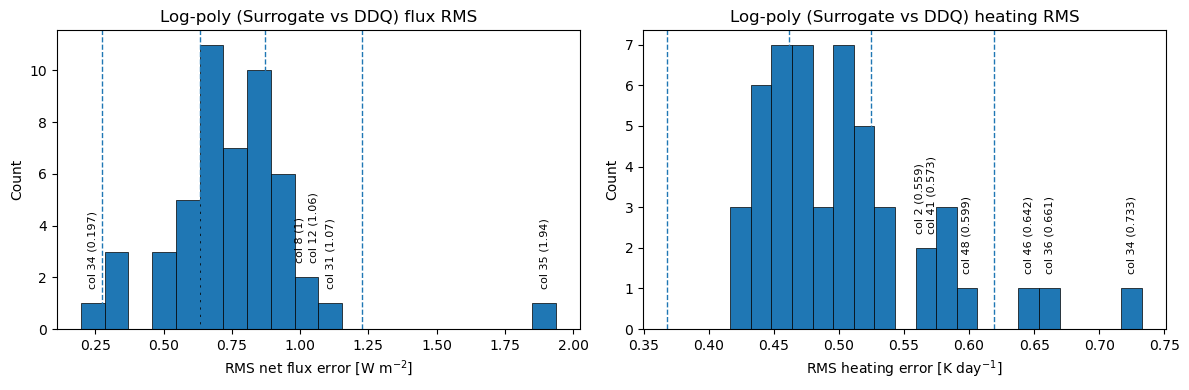


Labeled columns for PLS (Surrogate vs DDQ) flux RMS (PLS | Surrogate vs DDQ):
 column     value  bin_index
     34  5.763670          0
     32 20.323299          6
     46 21.543149          6
      3 29.284764          9
     12 37.334369         13
     13 39.726368         14
     35 53.169216         19

Labeled columns for PLS (Surrogate vs DDQ) heating RMS (PLS | Surrogate vs DDQ):
 column      value  bin_index
     14  38.854210          1
     23  56.569603          1
     40  64.524438          2
     38  64.929833          2
     33  78.854152          3
     19 116.974692          5
      2 140.659280          6
     43 349.688358         17
     46 356.622075         17
     47 365.189684         18
     35 403.100818         19


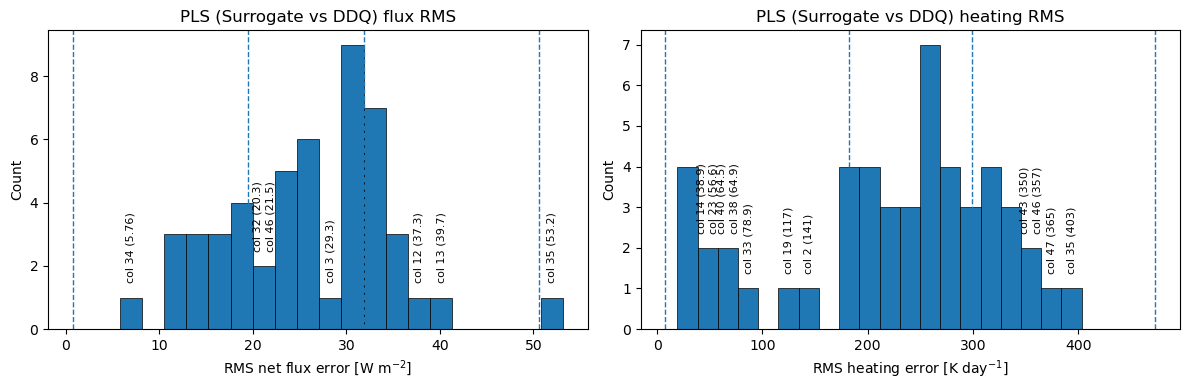


Labeled columns for Log-poly (Surrogate vs Dense) flux RMS (Log-poly | Surrogate vs Dense):
 column    value  bin_index
     34 0.315649          0
      1 0.463606          1
     33 0.464735          1
     36 0.559846          3
     47 1.470049         14
      0 1.486070         14
     12 1.663307         16
     31 1.758719         18
     35 1.901234         19

Labeled columns for Log-poly (Surrogate vs Dense) heating RMS (Log-poly | Surrogate vs Dense):
 column    value  bin_index
     14 1.180612          0
     16 1.444896          1
     39 1.565889          2
      3 1.782180          4
     43 1.801692          4
     18 2.214778          7
     45 2.284529          7
      2 2.722030         11
     23 2.779532         11
     20 3.024423         13
     27 3.313948         15
     48 3.427754         16
     46 3.631085         17
     36 3.941317         19


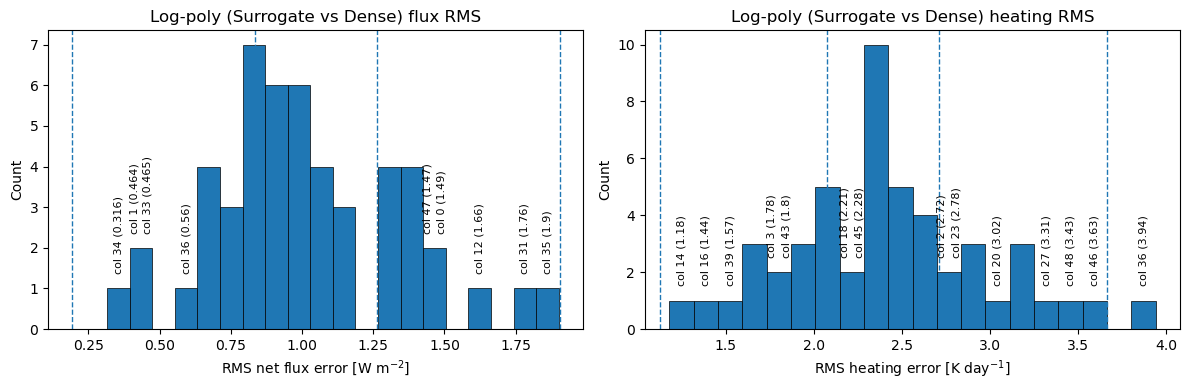


Labeled columns for PLS (Surrogate vs Dense) flux RMS (PLS | Surrogate vs Dense):
 column     value  bin_index
     34  5.718805          0
     46 20.708779          6
     19 35.020408         12
     12 36.575613         12
     13 39.351552         14
     35 53.349942         19

Labeled columns for PLS (Surrogate vs Dense) heating RMS (PLS | Surrogate vs Dense):
 column      value  bin_index
     23  58.733098          1
     38  63.717648          2
     40  67.064688          2
     33  81.008875          3
     19 115.447234          4
      2 142.412462          6
     47 364.551346         18
     35 401.879024         19


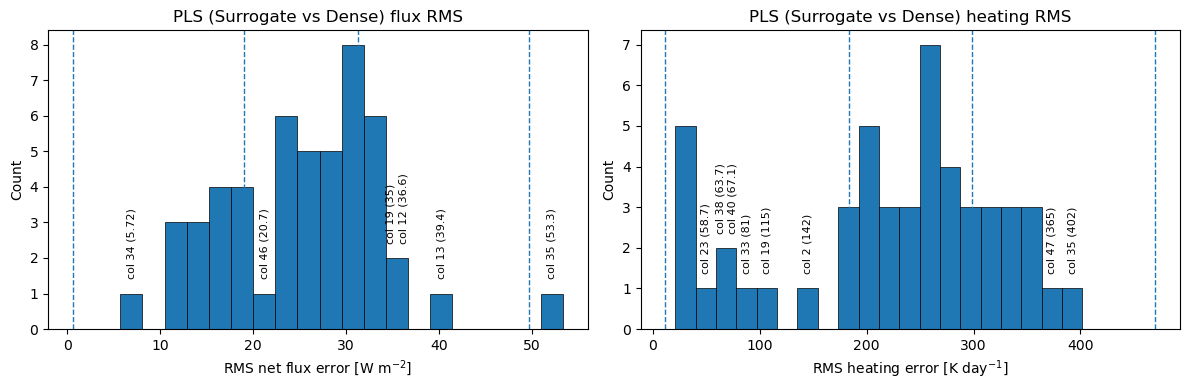

{'flux_table':    column      value  bin_index
 0      34   5.718805          0
 1      46  20.708779          6
 2      19  35.020408         12
 3      12  36.575613         12
 4      13  39.351552         14
 5      35  53.349942         19,
 'heating_table':    column       value  bin_index
 0      23   58.733098          1
 1      38   63.717648          2
 2      40   67.064688          2
 3      33   81.008875          3
 4      19  115.447234          4
 5       2  142.412462          6
 6      47  364.551346         18
 7      35  401.879024         19}

In [10]:
# Histograms + labeled outliers
plot_column_rms_histograms_labeled(logpoly_vs_ddq, bins=20)
plot_column_rms_histograms_labeled(pls_vs_ddq, bins=20)
plot_column_rms_histograms_labeled(logpoly_vs_dense, bins=20)
plot_column_rms_histograms_labeled(pls_vs_dense, bins=20)

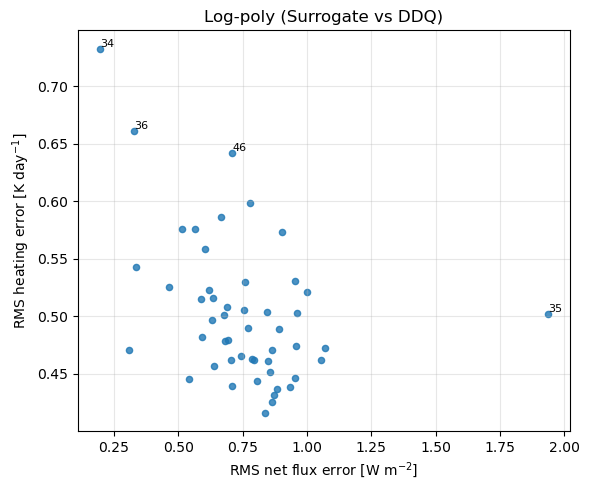

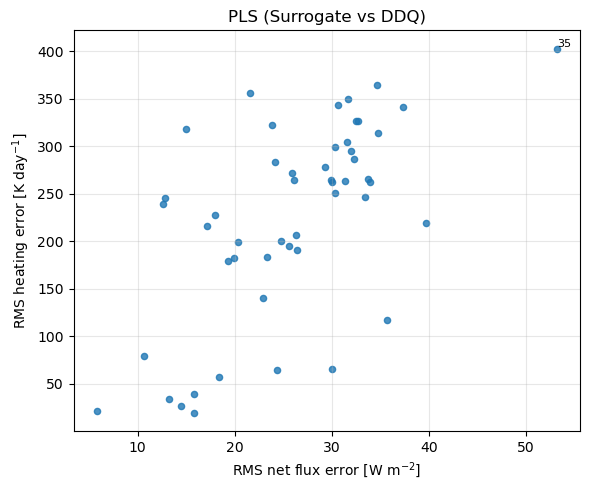

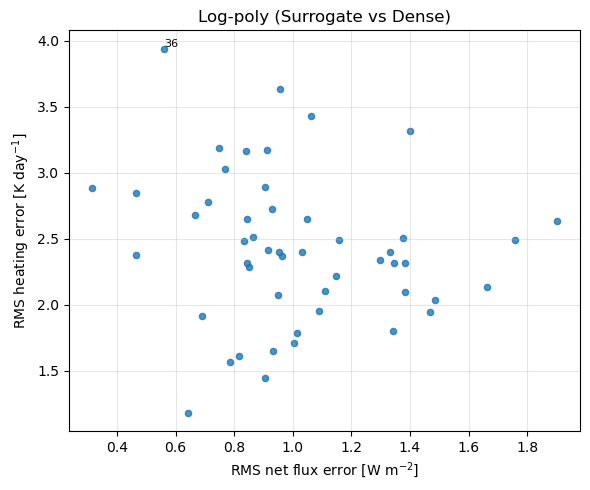

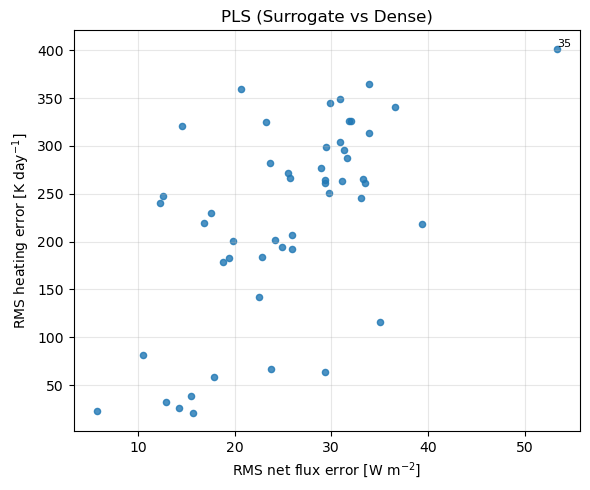

In [11]:
# Flux-vs-heating RMS scatter (labels IQR outliers)
plot_flux_vs_heating_rms_scatter(logpoly_vs_ddq)
plot_flux_vs_heating_rms_scatter(pls_vs_ddq)
plot_flux_vs_heating_rms_scatter(logpoly_vs_dense)
plot_flux_vs_heating_rms_scatter(pls_vs_dense)